  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
=== DATA SPLIT ===
Training: 4457
Testing : 1115

=== TF-IDF SHAPES ===
Train: (4457, 7440)
Test : (1115, 7440)

Logistic Regression Performance:
  Accuracy  : 0.97
  Precision : 0.96
  Recall    : 1.00
  F1-Score  : 0.98
  Confusion Matrix:
    [[113, 36], [0, 966]]

Random Forest Performance:
  Accuracy  : 0.98
  Precision : 0.98
  Recall    : 1.00
  F1-Score  : 0.99
  Confusion Matrix:
    [[130, 19], [0, 966]]

Naive Bayes Performance:
  Accuracy  : 0.98
  Precision : 0.97
  Recall    : 1.00
  F1-Score  : 0.99
  Confusion Matrix:
    [[123, 26], [0, 966]]


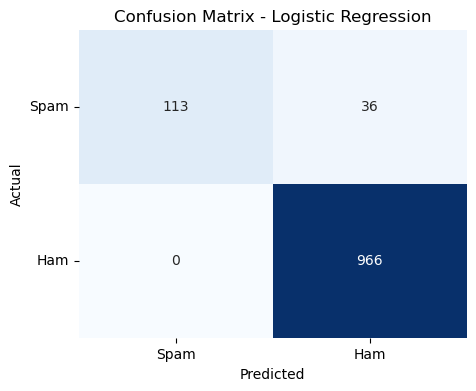

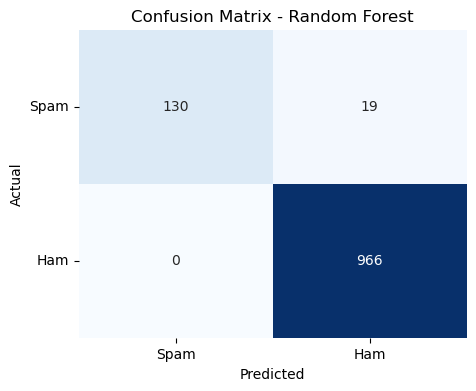

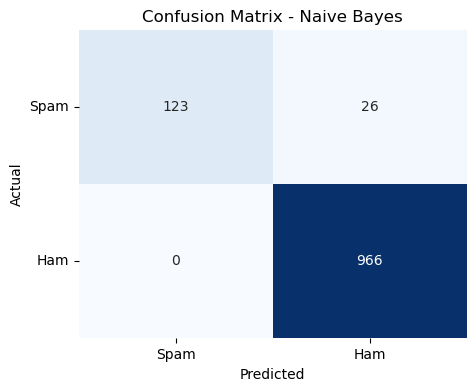


=== SANITY CHECK ===

Message: Free entry in 2 a weekly competition!
Logistic Regression: Ham
Random Forest      : Ham
Naive Bayes        : Spam

Message: I will meet you at the cafe tomorrow
Logistic Regression: Ham
Random Forest      : Ham
Naive Bayes        : Ham

Message: Congratulations, you won a free ticket
Logistic Regression: Ham
Random Forest      : Ham
Naive Bayes        : Ham


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

RANDOM_STATE = 42

#1  Load the dataset
df = pd.read_csv("mail_l7_dataset.csv")

# Replace missing values with empty string
df = df.where(pd.notnull(df), "")

print(df.head())

# 2) Encode labels
# spam = 0, ham = 1

df.loc[df["Category"].str.lower().str.strip() == "spam", "Category"] = 0
df.loc[df["Category"].str.lower().str.strip() == "ham", "Category"] = 1

#2 Split features (X) and target (y)
X = df["Message"].astype(str)
y = df["Category"].astype(int)

# --------------------------------
# 3) Train Test Split (80/20)
# --------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("=== DATA SPLIT ===")
print("Training:", X_train.shape[0])
print("Testing :", X_test.shape[0])

# --------------------------------
# 4) TF-IDF Vectorization
# --------------------------------
tfidf = TfidfVectorizer(stop_words="english", lowercase=True)

X_train_features = tfidf.fit_transform(X_train)
X_test_features = tfidf.transform(X_test)

print("\n=== TF-IDF SHAPES ===")
print("Train:", X_train_features.shape)
print("Test :", X_test_features.shape)

# 5) Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_features, y_train)

lr_pred = lr_model.predict(X_test_features)

# 6) Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)

rf_model.fit(X_train_features, y_train)

rf_pred = rf_model.predict(X_test_features)

# 7) Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train_features, y_train)

nb_pred = nb_model.predict(X_test_features)

# 8) Evaluation Functions
# --------------------------------
def print_pretty_metrics(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)
    
    print(f"\n{name} Performance:")
    print(f"  Accuracy  : {acc:.2f}")
    print(f"  Precision : {prec:.2f}")
    print(f"  Recall    : {rec:.2f}")
    print(f"  F1-Score  : {f1:.2f}")
    print("  Confusion Matrix:")
    print(f"    {cm.tolist()}")

print_pretty_metrics("Logistic Regression", y_test, lr_pred)
print_pretty_metrics("Random Forest", y_test, rf_pred)
print_pretty_metrics("Naive Bayes", y_test, nb_pred)

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(ticks=[0.5,1.5], labels=["Spam", "Ham"])
    plt.yticks(ticks=[0.5,1.5], labels=["Spam", "Ham"], rotation=0)
    plt.show()

# Plot for each model
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression")
plot_confusion_matrix(y_test, rf_pred, "Random Forest")
plot_confusion_matrix(y_test, nb_pred, "Naive Bayes")

    
# 9) Sanity Check Predictions

test_messages = [
"Free entry in 2 a weekly competition!",
"I will meet you at the cafe tomorrow",
"Congratulations, you won a free ticket"
]

test_features = tfidf.transform(test_messages)

lr_preds = lr_model.predict(test_features)
rf_preds = rf_model.predict(test_features)
nb_preds = nb_model.predict(test_features)

def label(v):
    return "Ham" if v == 1 else "Spam"

print("\n=== SANITY CHECK ===")

for i in range(len(test_messages)):

    print("\nMessage:", test_messages[i])
    print("Logistic Regression:", label(lr_preds[i]))
    print("Random Forest      :", label(rf_preds[i]))
    print("Naive Bayes        :", label(nb_preds[i]))






